In [1]:
#Clean 10K Dataset load
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/sales_10k_clean.csv")

sales["date"] = pd.to_datetime(sales["date"])

print("Records:", len(sales))
print("Date Range:", sales["date"].min(), "to", sales["date"].max())
print("Columns:", sales.columns.tolist())

Matplotlib is building the font cache; this may take a moment.


Records: 10000
Date Range: 2022-01-01 00:00:00 to 2025-12-31 00:00:00
Columns: ['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']


In [2]:
#Daily sales Demand
daily_sales = (
    sales.groupby("date")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

daily_sales.head()

,date,units_sold,revenue,transactions
0,2022-01-01,3,2109.19,1
1,2022-01-02,7,1549.64,3
2,2022-01-03,18,8970.86,4
3,2022-01-04,14,7319.35,4
4,2022-01-06,25,21931.89,4


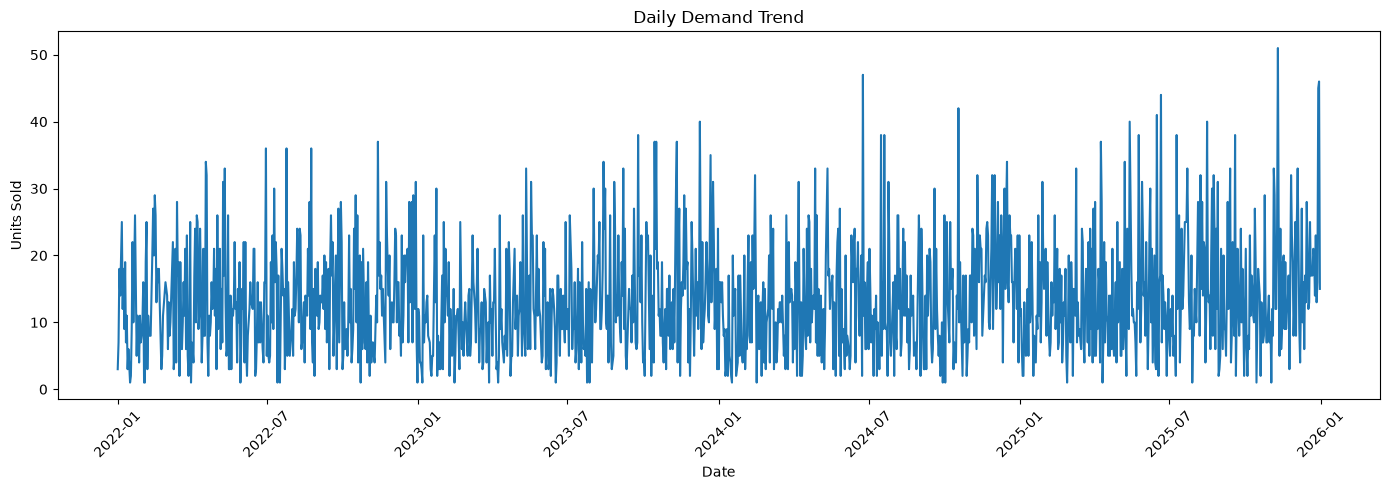

In [3]:
#Demand Trend Chart
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["units_sold"]
)

plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
#Basic business numbers
print("Total Units Sold:", sales["quantity"].sum())
print("Total Revenue:", sales["total_value"].sum())
print("Total Transactions:", sales["receipt_id"].nunique())
print("Unique SKUs:", sales["sku_id"].nunique())
print("Unique Stores:", sales["store_id"].nunique())

Total Units Sold: 18891
Total Revenue: 11186569.780000001
Total Transactions: 5201
Unique SKUs: 3482
Unique Stores: 30


In [5]:
#Weekly sales summary
weekly_sales = (
    sales
    .set_index("date")
    .resample("W")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

weekly_sales.head()

,date,units_sold,revenue,transactions
0,2022-01-02,10,3658.83,4
1,2022-01-09,96,52530.55,24
2,2022-01-16,47,33770.98,16
3,2022-01-23,87,55573.46,21
4,2022-01-30,55,27019.39,15


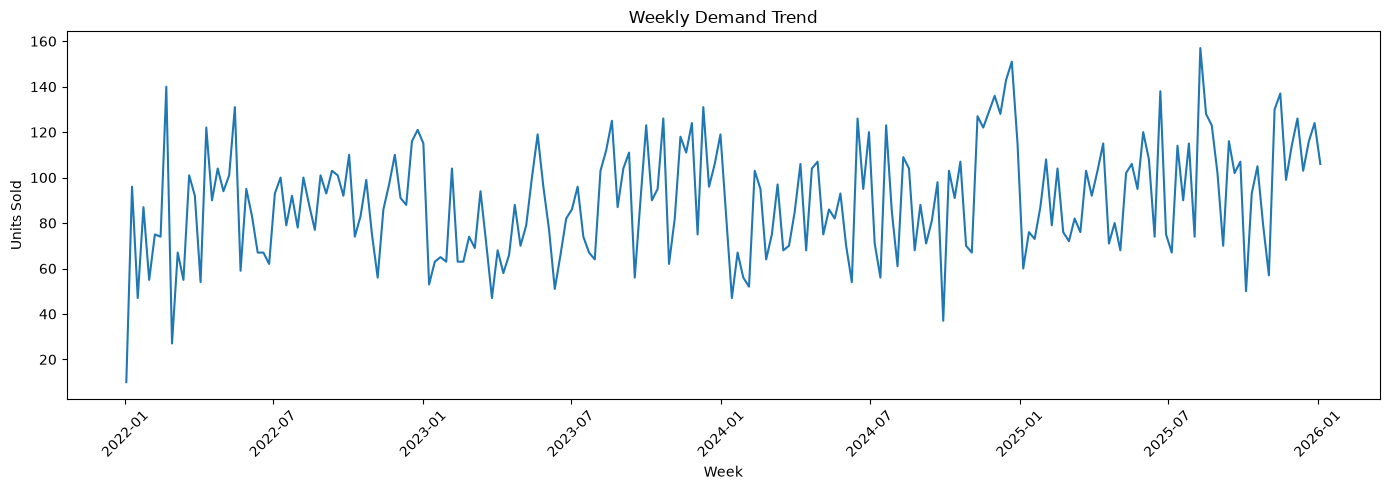

In [6]:
#Weekly Demand Trend Chart
plt.figure(figsize=(14, 5))

plt.plot(
    weekly_sales["date"],
    weekly_sales["units_sold"]
)

plt.title("Weekly Demand Trend")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
#Weekly sales summary statistics
print("Total Weeks:", len(weekly_sales))
print("Average Weekly Units:", weekly_sales["units_sold"].mean())
print("Minimum Weekly Units:", weekly_sales["units_sold"].min())
print("Maximum Weekly Units:", weekly_sales["units_sold"].max())

Total Weeks: 210
Average Weekly Units: 89.95714285714286
Minimum Weekly Units: 10
Maximum Weekly Units: 157


In [10]:
#SKU wise sales summary
sku_sales = (
    sales.groupby("sku_id")
    .agg(
        total_units=("quantity", "sum"),
        total_revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

sku_sales = sku_sales.sort_values(
    "total_units",
    ascending=False
)

sku_sales.head(10)

,sku_id,total_units,total_revenue,transactions
2998,SKU04321,1156,1042524.96,591
3190,SKU04596,294,92670.83,160
2582,SKU03727,159,249717.50,90
2871,SKU04154,146,47949.06,72
1483,SKU02141,107,48509.73,61
660,SKU00953,100,25779.44,45
2279,SKU03292,96,14160.06,47
727,SKU01045,92,38139.45,44
689,SKU00994,91,49172.37,52
137,SKU00190,87,11823.82,47


In [11]:
#top 10 movers
top_10_skus = sku_sales.head(10)

print("Top 10 Selling SKUs:")
display(top_10_skus)

Top 10 Selling SKUs:


,sku_id,total_units,total_revenue,transactions
2998,SKU04321,1156,1042524.96,591
3190,SKU04596,294,92670.83,160
2582,SKU03727,159,249717.50,90
2871,SKU04154,146,47949.06,72
1483,SKU02141,107,48509.73,61
660,SKU00953,100,25779.44,45
2279,SKU03292,96,14160.06,47
727,SKU01045,92,38139.45,44
689,SKU00994,91,49172.37,52
137,SKU00190,87,11823.82,47


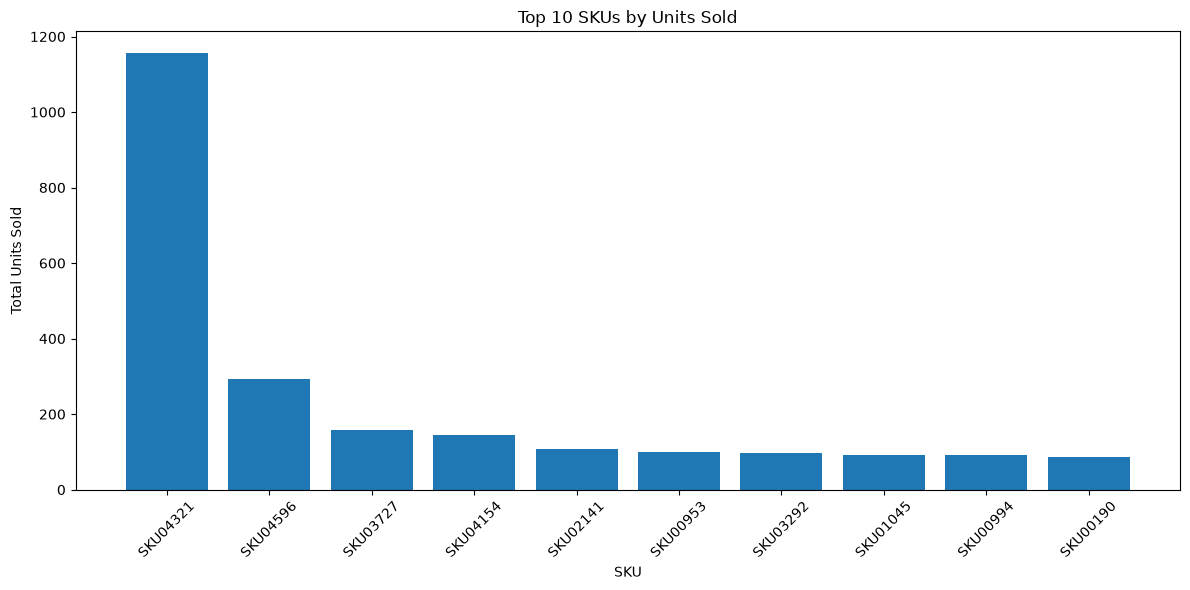

In [12]:
#Top movers chart
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_skus["sku_id"].astype(str),
    top_10_skus["total_units"]
)

plt.title("Top 10 SKUs by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
#slow movers 
slow_10_skus = sku_sales.tail(10).sort_values(
    "total_units",
    ascending=True
)

print("Bottom 10 SKUs by Units Sold:")
display(slow_10_skus)

Bottom 10 SKUs by Units Sold:


,sku_id,total_units,total_revenue,transactions
2630,SKU03802,1,37.67,1
2635,SKU03811,1,239.04,1
2637,SKU03813,1,1597.17,1
2646,SKU03829,1,660.71,1
1866,SKU02723,1,3042.95,1
3459,SKU04969,1,658.15,1
735,SKU01055,1,916.38,1
2075,SKU03013,1,101.21,1
2081,SKU03022,1,86.56,1
2094,SKU03038,1,204.05,1


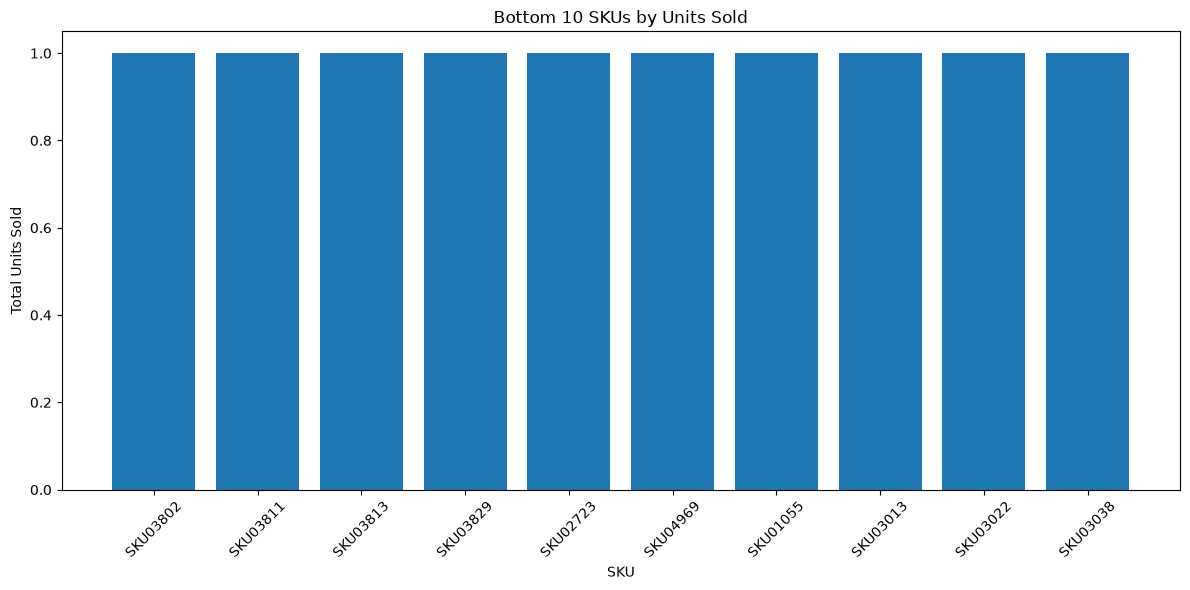

In [14]:
#slow movers chart
plt.figure(figsize=(12, 6))

plt.bar(
    slow_10_skus["sku_id"].astype(str),
    slow_10_skus["total_units"]
)

plt.title("Bottom 10 SKUs by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
#promotion flag
sales["is_promotion"] = sales["promo_id"].notna()

sales["is_promotion"].value_counts()

is_promotion
False    7969
True     2031
Name: count, dtype: int64

In [16]:
#promotion vs non-promotion summary
promo_summary = (
    sales.groupby("is_promotion")
    .agg(
        transactions=("receipt_id", "nunique"),
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        avg_quantity=("quantity", "mean"),
        avg_revenue=("total_value", "mean")
    )
    .reset_index()
)

promo_summary

,is_promotion,transactions,units_sold,revenue,avg_quantity,avg_revenue
0,False,4237,15056,9465685.32,1.889321,1187.813442
1,True,1236,3835,1720884.46,1.888232,847.308941


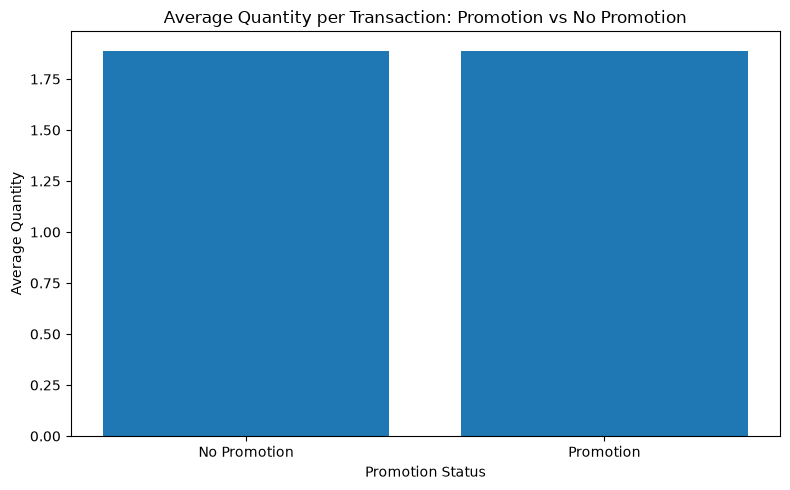

In [17]:
#promotion vs non-promotion chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_summary["avg_quantity"]
)

plt.title("Average Quantity per Transaction: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Quantity")

plt.tight_layout()
plt.show()

In [19]:
promo_avg = sales.loc[
    sales["is_promotion"], "quantity"
].mean()

non_promo_avg = sales.loc[
    ~sales["is_promotion"], "quantity"
].mean()

difference_pct = (
    (promo_avg - non_promo_avg)
    / non_promo_avg
) * 100

print("Average Quantity - Promotion:", round(promo_avg, 2))
print("Average Quantity - No Promotion:", round(non_promo_avg, 2))
print("Difference:", round(difference_pct, 2), "%")

Average Quantity - Promotion: 1.89
Average Quantity - No Promotion: 1.89
Difference: -0.06 %


In [18]:
#discount comparison
print("Average discount when promotion exists:",
      sales.loc[sales["is_promotion"], "discount_pct"].mean())

print("Average discount when no promotion exists:",
      sales.loc[~sales["is_promotion"], "discount_pct"].mean())

Average discount when promotion exists: 29.520384047267353
Average discount when no promotion exists: 0.0


In [21]:
#Monthly demand
monthly_sales = (
    sales
    .set_index("date")
    .resample("ME")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head()

,date,units_sold,revenue,transactions
0,2022-01-31,305,180532.72,83
1,2022-02-28,322,190441.87,77
2,2022-03-31,336,180991.21,94
3,2022-04-30,424,240911.67,107
4,2022-05-31,397,264514.35,114


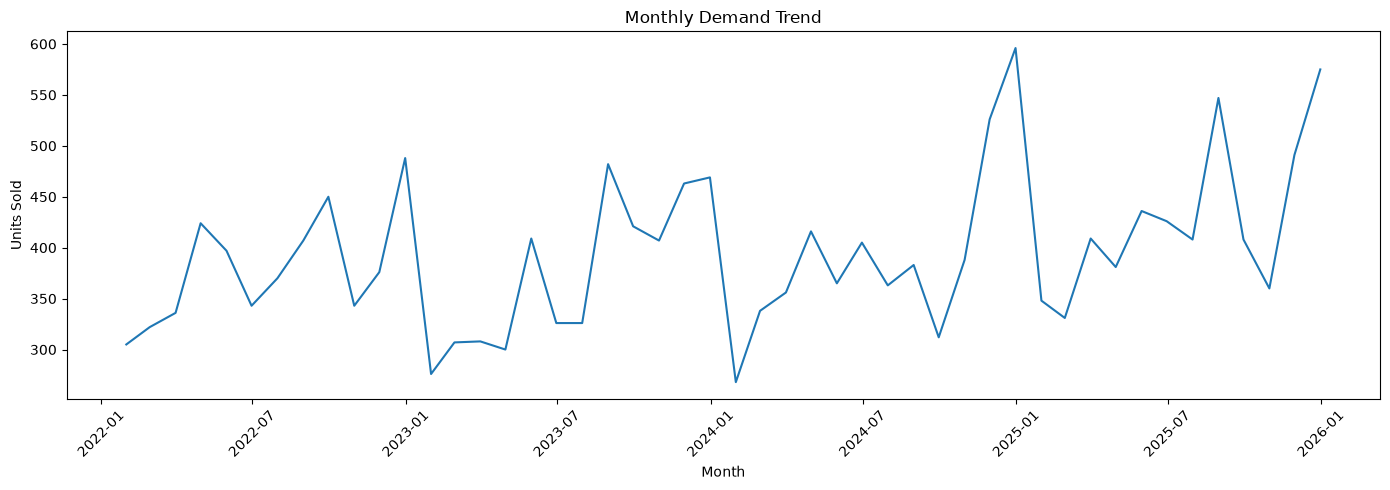

In [22]:
#monthly demand chart
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["units_sold"]
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
#month wise average demand
month_pattern = (
    sales.assign(
        month=sales["date"].dt.month
    )
    .groupby("month")
    .agg(
        avg_units=("quantity", "mean"),
        total_units=("quantity", "sum")
    )
    .reset_index()
)

month_pattern

,month,avg_units,total_units
0,1,1.824695,1197
1,2,1.911635,1298
2,3,1.839426,1409
3,4,1.889441,1521
4,5,1.879532,1607
5,6,1.863354,1500
6,7,1.943046,1467
7,8,1.939232,1819
8,9,1.885071,1591
9,10,1.922978,1498


In [2]:
import pandas as pd
inventory = pd.read_csv(
    "../data/retail_clean_dataset/inventory_snapshot.csv"
)

print("Inventory Records:", len(inventory))
print("Columns:", inventory.columns.tolist())

Inventory Records: 21228
Columns: ['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


In [3]:
inventory.head()

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,323,72,22,2025-05-17
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,433,96,34,2025-05-20
3,ST19,SKU02907,178,34,13,2025-08-03
4,ST05,SKU01023,333,97,22,2025-07-12


In [4]:
print(inventory.info())
inventory.head(10)
inventory.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 21228 entries, 0 to 21227
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   store_id           21228 non-null  str  
 1   sku_id             21228 non-null  str  
 2   stock_on_hand      21228 non-null  int64
 3   reorder_point      21228 non-null  int64
 4   safety_stock       21228 non-null  int64
 5   last_restock_date  21228 non-null  str  
dtypes: int64(3), str(3)
memory usage: 995.2 KB
None


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
count,21228,21228,21228.000000,21228.000000,21228.000000,21228
unique,30,4481,NaN,NaN,NaN,221
top,ST03,SKU01318,NaN,NaN,NaN,2025-12-09
freq,747,30,NaN,NaN,NaN,175
mean,NaN,NaN,154.978566,59.906774,20.920859,NaN
std,NaN,NaN,135.183820,23.376075,9.875016,NaN
min,NaN,NaN,0.000000,20.000000,4.000000,NaN
25%,NaN,NaN,40.000000,39.000000,13.000000,NaN
50%,NaN,NaN,125.000000,60.000000,20.000000,NaN
75%,NaN,NaN,240.000000,80.000000,27.000000,NaN


In [5]:
#low stock flag
inventory["low_stock"] = (
    inventory["stock_on_hand"] <= inventory["reorder_point"]
)

print("Low Stock Records:", inventory["low_stock"].sum())
print("Normal Stock Records:", (~inventory["low_stock"]).sum())

Low Stock Records: 5862
Normal Stock Records: 15366


In [6]:
#safety stock risk
inventory["below_safety_stock"] = (
    inventory["stock_on_hand"] < inventory["safety_stock"]
)

print(
    "Below Safety Stock:",
    inventory["below_safety_stock"].sum()
)

Below Safety Stock: 3823


In [7]:
#inventory summary 
inventory_summary = inventory[
    [
        "stock_on_hand",
        "reorder_point",
        "safety_stock"
    ]
].describe()

inventory_summary

,stock_on_hand,reorder_point,safety_stock
count,21228.000000,21228.000000,21228.000000
mean,154.978566,59.906774,20.920859
std,135.183820,23.376075,9.875016
min,0.000000,20.000000,4.000000
25%,40.000000,39.000000,13.000000
50%,125.000000,60.000000,20.000000
75%,240.000000,80.000000,27.000000
max,600.000000,100.000000,50.000000


In [8]:
low_stock_items = inventory[
    inventory["low_stock"]
].copy()

low_stock_items = low_stock_items.sort_values(
    "stock_on_hand",
    ascending=True
)

low_stock_items.head(20)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date,low_stock,below_safety_stock
154,ST16,SKU01547,0,79,26,2025-10-01,True,True
148,ST10,SKU00830,0,87,23,2025-08-31,True,True
146,ST05,SKU02930,0,23,8,2025-09-12,True,True
142,ST11,SKU00264,0,31,7,2025-08-21,True,True
140,ST06,SKU04350,0,92,26,2025-08-16,True,True
138,ST29,SKU04105,0,83,32,2025-09-25,True,True
132,ST04,SKU02355,0,48,17,2025-10-10,True,True
122,ST07,SKU01485,0,55,27,2025-08-07,True,True
120,ST26,SKU02747,0,26,8,2025-09-02,True,True
44,ST28,SKU04551,0,80,39,2025-09-05,True,True


In [10]:
import pandas as pd

# 10,000 sales dataset
sales = pd.read_csv("../data/sales_10k_clean.csv")

# Inventory dataset
inventory = pd.read_csv(
    "../data/retail_clean_dataset/inventory_snapshot.csv"
)

# 10K sales mein aaye Store + SKU combinations
sales_pairs = sales[["store_id", "sku_id"]].drop_duplicates()

# Inventory ko 10K sales scope ke saath align karna
inventory_10k = inventory.merge(
    sales_pairs,
    on=["store_id", "sku_id"],
    how="inner"
)

print("Sales records:", len(sales))
print("Inventory records after 10K alignment:", len(inventory_10k))

Sales records: 10000
Inventory records after 10K alignment: 1556


In [12]:
# Low stock condition
inventory_10k["low_stock"] = (
    inventory_10k["stock_on_hand"] <= inventory_10k["reorder_point"]
)

# Low stock records
low_stock_10k = inventory_10k[
    inventory_10k["low_stock"]
].copy()

print("Low Stock Records:", len(low_stock_10k))

low_stock_10k.head(20)

Low Stock Records: 1024


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date,low_stock
1,ST06,SKU04913,0,26,9,2025-09-09,True
2,ST13,SKU03088,0,97,40,2025-08-14,True
3,ST30,SKU04489,0,74,37,2025-09-17,True
6,ST20,SKU02983,0,77,25,2025-09-05,True
7,ST19,SKU03633,0,81,27,2025-09-15,True
9,ST07,SKU01485,0,55,27,2025-08-07,True
11,ST29,SKU04105,0,83,32,2025-09-25,True
12,ST06,SKU04350,0,92,26,2025-08-16,True
13,ST05,SKU02930,0,23,8,2025-09-12,True
14,ST10,SKU00830,0,87,23,2025-08-31,True


In [13]:
# Check inventory below safety stock

inventory_10k["below_safety_stock"] = (
    inventory_10k["stock_on_hand"] < inventory_10k["safety_stock"]
)

print(
    "Below Safety Stock Records:",
    inventory_10k["below_safety_stock"].sum()
)

Below Safety Stock Records: 917


In [14]:
print("Total Inventory Records:", len(inventory_10k))

print(
    "Low Stock Records:",
    inventory_10k["low_stock"].sum()
)

print(
    "Below Safety Stock Records:",
    inventory_10k["below_safety_stock"].sum()
)

print(
    "Normal Stock Records:",
    (
        (~inventory_10k["low_stock"]) &
        (~inventory_10k["below_safety_stock"])
    ).sum()
)

Total Inventory Records: 1556
Low Stock Records: 1024
Below Safety Stock Records: 917
Normal Stock Records: 532


In [15]:
#LOW STOCK %
total_inventory = len(inventory_10k)

low_stock_pct = (
    inventory_10k["low_stock"].sum()
    / total_inventory
) * 100

below_safety_pct = (
    inventory_10k["below_safety_stock"].sum()
    / total_inventory
) * 100

print(f"Low Stock Percentage: {low_stock_pct:.2f}%")
print(f"Below Safety Stock Percentage: {below_safety_pct:.2f}%")

Low Stock Percentage: 65.81%
Below Safety Stock Percentage: 58.93%


In [16]:
#TOP MOVERS
top_skus = (
    sales.groupby("sku_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 SKUs by Units Sold:")
print(top_skus)

Top 10 SKUs by Units Sold:
sku_id
SKU04321    1156
SKU04596     294
SKU03727     159
SKU04154     146
SKU02141     107
SKU00953     100
SKU03292      96
SKU01045      92
SKU00994      91
SKU00190      87
Name: quantity, dtype: int64


In [20]:
import pandas as pd

sales = pd.read_csv("../data/sales_10k_clean.csv")
inventory_10k = pd.read_csv(
    "../data/retail_clean_dataset/inventory_snapshot.csv"
)

sales["date"] = pd.to_datetime(sales["date"])

sales_store_sku = (
    sales.groupby(["store_id", "sku_id"])
    .agg(
        total_units_sold=("quantity", "sum"),
        total_revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

print("Sales Store-SKU combinations:", len(sales_store_sku))
sales_store_sku.head(10)

Sales Store-SKU combinations: 8353


,store_id,sku_id,total_units_sold,total_revenue,transactions
0,ST01,SKU00016,1,3478.65,1
1,ST01,SKU00079,3,298.63,1
2,ST01,SKU00083,2,667.08,1
3,ST01,SKU00093,2,316.12,1
4,ST01,SKU00106,1,140.16,1
5,ST01,SKU00114,1,169.83,1
6,ST01,SKU00155,2,1171.56,1
7,ST01,SKU00166,1,830.77,1
8,ST01,SKU00183,1,252.07,1
9,ST01,SKU00188,1,201.41,1


In [21]:
sales_inventory = sales_store_sku.merge(
    inventory_10k,
    on=["store_id", "sku_id"],
    how="left"
)

print("Combined records:", len(sales_inventory))
print("Missing inventory records:",
      sales_inventory["stock_on_hand"].isna().sum())

sales_inventory.head(10)

Combined records: 8353
Missing inventory records: 6797


,store_id,sku_id,total_units_sold,total_revenue,transactions,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST01,SKU00016,1,3478.65,1,NaN,NaN,NaN,NaN
1,ST01,SKU00079,3,298.63,1,0.0,87.0,42.0,2025-09-08
2,ST01,SKU00083,2,667.08,1,NaN,NaN,NaN,NaN
3,ST01,SKU00093,2,316.12,1,NaN,NaN,NaN,NaN
4,ST01,SKU00106,1,140.16,1,NaN,NaN,NaN,NaN
5,ST01,SKU00114,1,169.83,1,NaN,NaN,NaN,NaN
6,ST01,SKU00155,2,1171.56,1,207.0,57.0,21.0,2025-05-24
7,ST01,SKU00166,1,830.77,1,NaN,NaN,NaN,NaN
8,ST01,SKU00183,1,252.07,1,NaN,NaN,NaN,NaN
9,ST01,SKU00188,1,201.41,1,NaN,NaN,NaN,NaN


In [23]:
high_demand_threshold = sales_store_sku["total_units_sold"].quantile(0.75)

sales_inventory["high_demand"] = (
    sales_inventory["total_units_sold"] >= high_demand_threshold
)

sales_inventory["low_stock"] = (
    sales_inventory["stock_on_hand"] <= sales_inventory["reorder_point"]
)

sales_inventory["replenishment_attention"] = (
    sales_inventory["high_demand"] &
    sales_inventory["low_stock"]
)

print("High Demand Threshold:", high_demand_threshold)

print(
    "High Demand + Low Stock:",
    sales_inventory["replenishment_attention"].sum()
)

High Demand Threshold: 3.0
High Demand + Low Stock: 411


In [25]:
attention_items = (
    sales_inventory[
        sales_inventory["replenishment_attention"]
    ]
    .sort_values(
        ["total_units_sold", "stock_on_hand"],
        ascending=[False, True]
    )
)

# Add the missing safety-stock flag on the filtered attention-items dataframe
attention_items["below_safety_stock"] = (
    attention_items["stock_on_hand"] < attention_items["safety_stock"]
)

attention_items[
    [
        "store_id",
        "sku_id",
        "total_units_sold",
        "total_revenue",
        "stock_on_hand",
        "reorder_point",
        "safety_stock",
        "low_stock",
        "below_safety_stock"
    ]
].head(20)

,store_id,sku_id,total_units_sold,total_revenue,stock_on_hand,reorder_point,safety_stock,low_stock,below_safety_stock
7518,ST28,SKU04321,59,51428.58,0.0,64.0,19.0,True,True
5774,ST21,SKU04321,58,51428.59,0.0,30.0,11.0,True,True
5325,ST20,SKU04321,39,34750.98,0.0,71.0,18.0,True,True
3036,ST11,SKU04321,35,30899.06,0.0,96.0,33.0,True,True
916,ST04,SKU04321,33,30876.95,0.0,24.0,7.0,True,True
595,ST03,SKU04321,30,26783.73,0.0,40.0,16.0,True,True
3953,ST15,SKU04321,29,27877.70,0.0,71.0,31.0,True,True
5727,ST21,SKU03727,27,39383.97,0.0,53.0,23.0,True,True
3255,ST12,SKU04321,26,24696.76,0.0,24.0,6.0,True,True
6733,ST25,SKU04321,23,20513.18,0.0,68.0,26.0,True,True


In [27]:
sales_inventory["below_safety_stock"] = (
    sales_inventory["stock_on_hand"] < sales_inventory["safety_stock"]
)

print("===== SALES + INVENTORY SUMMARY =====")

print("Total Store-SKU combinations:", len(sales_inventory))

print(
    "High Demand:",
    sales_inventory["high_demand"].sum()
)

print(
    "Low Stock:",
    sales_inventory["low_stock"].sum()
)

print(
    "Below Safety Stock:",
    sales_inventory["below_safety_stock"].sum()
)

print(
    "High Demand + Low Stock:",
    sales_inventory["replenishment_attention"].sum()
)

===== SALES + INVENTORY SUMMARY =====
Total Store-SKU combinations: 8353
High Demand: 2538
Low Stock: 1024
Below Safety Stock: 917
High Demand + Low Stock: 411


In [28]:
total = len(sales_inventory)

print(
    f"High Demand %: "
    f"{sales_inventory['high_demand'].sum() / total * 100:.2f}%"
)

print(
    f"Low Stock %: "
    f"{sales_inventory['low_stock'].sum() / total * 100:.2f}%"
)

print(
    f"Below Safety Stock %: "
    f"{sales_inventory['below_safety_stock'].sum() / total * 100:.2f}%"
)

print(
    f"High Demand + Low Stock %: "
    f"{sales_inventory['replenishment_attention'].sum() / total * 100:.2f}%"
)

High Demand %: 30.38%
Low Stock %: 12.26%
Below Safety Stock %: 10.98%
High Demand + Low Stock %: 4.92%


In [29]:
combined_analysis = sales_inventory[
    [
        "store_id",
        "sku_id",
        "total_units_sold",
        "total_revenue",
        "transactions",
        "stock_on_hand",
        "reorder_point",
        "safety_stock",
        "low_stock",
        "below_safety_stock",
        "high_demand",
        "replenishment_attention"
    ]
].copy()

combined_analysis.head(20)

,store_id,sku_id,total_units_sold,total_revenue,transactions,stock_on_hand,reorder_point,safety_stock,low_stock,below_safety_stock,high_demand,replenishment_attention
0,ST01,SKU00016,1,3478.65,1,NaN,NaN,NaN,False,False,False,False
1,ST01,SKU00079,3,298.63,1,0.0,87.0,42.0,True,True,True,True
2,ST01,SKU00083,2,667.08,1,NaN,NaN,NaN,False,False,False,False
3,ST01,SKU00093,2,316.12,1,NaN,NaN,NaN,False,False,False,False
4,ST01,SKU00106,1,140.16,1,NaN,NaN,NaN,False,False,False,False
5,ST01,SKU00114,1,169.83,1,NaN,NaN,NaN,False,False,False,False
6,ST01,SKU00155,2,1171.56,1,207.0,57.0,21.0,False,False,False,False
7,ST01,SKU00166,1,830.77,1,NaN,NaN,NaN,False,False,False,False
8,ST01,SKU00183,1,252.07,1,NaN,NaN,NaN,False,False,False,False
9,ST01,SKU00188,1,201.41,1,NaN,NaN,NaN,False,False,False,False


In [30]:
attention_items = combined_analysis[
    combined_analysis["replenishment_attention"]
].copy()

attention_items = attention_items.sort_values(
    "total_units_sold",
    ascending=False
)

attention_items.head(20)

,store_id,sku_id,total_units_sold,total_revenue,transactions,stock_on_hand,reorder_point,safety_stock,low_stock,below_safety_stock,high_demand,replenishment_attention
7518,ST28,SKU04321,59,51428.58,21,0.0,64.0,19.0,True,True,True,True
5774,ST21,SKU04321,58,51428.59,33,0.0,30.0,11.0,True,True,True,True
5325,ST20,SKU04321,39,34750.98,21,0.0,71.0,18.0,True,True,True,True
3036,ST11,SKU04321,35,30899.06,19,0.0,96.0,33.0,True,True,True,True
916,ST04,SKU04321,33,30876.95,19,0.0,24.0,7.0,True,True,True,True
595,ST03,SKU04321,30,26783.73,17,0.0,40.0,16.0,True,True,True,True
3953,ST15,SKU04321,29,27877.70,16,0.0,71.0,31.0,True,True,True,True
5727,ST21,SKU03727,27,39383.97,10,0.0,53.0,23.0,True,True,True,True
3255,ST12,SKU04321,26,24696.76,15,0.0,24.0,6.0,True,True,True,True
6733,ST25,SKU04321,23,20513.18,13,0.0,68.0,26.0,True,True,True,True
